<a href="https://colab.research.google.com/github/miriamamin1213-ux/Seed42_Models/blob/main/GenericTransformerHecktorNoSmote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(726, 17)
(423, 12)
train sample: HPV Status
1.0    320
0.0     18
Name: count, dtype: int64 

test sample: HPV Status
1.0    80
0.0     5
Name: count, dtype: int64


/tmp/ipykernel_2243/2643955540.py:72: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['T-stage'] = df['T-stage'].replace({
/tmp/ipykernel_2243/2643955540.py:80: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['N-stage'] = df['N-stage'].replace({
/tmp/ipykernel_2243/2643955540.py:87: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_si

Epoch 50, Train=0.3416, Test=0.2719 Best Epoch=50
Epoch 100, Train=0.2283, Test=0.3676 Best Epoch=61
Epoch 150, Train=0.1991, Test=0.3839 Best Epoch=61
Epoch 200, Train=0.1680, Test=0.4109 Best Epoch=61
Epoch 250, Train=0.1563, Test=0.4180 Best Epoch=61
Epoch 300, Train=0.1701, Test=0.4311 Best Epoch=61
Epoch 350, Train=0.0999, Test=0.5509 Best Epoch=61
Epoch 400, Train=0.1929, Test=0.6729 Best Epoch=61
Epoch 450, Train=0.0948, Test=0.5781 Best Epoch=61
Epoch 500, Train=0.0897, Test=0.7209 Best Epoch=61
Best Test Loss = 0.23038551211357117
Best Epoch = 61
results:               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         5
           1     0.9412    1.0000    0.9697        80

    accuracy                         0.9412        85
   macro avg     0.4706    0.5000    0.4848        85
weighted avg     0.8858    0.9412    0.9127        85

Balanced Accuracy: 0.5000
F1-score:          0.9697
AUC:               0.9300


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


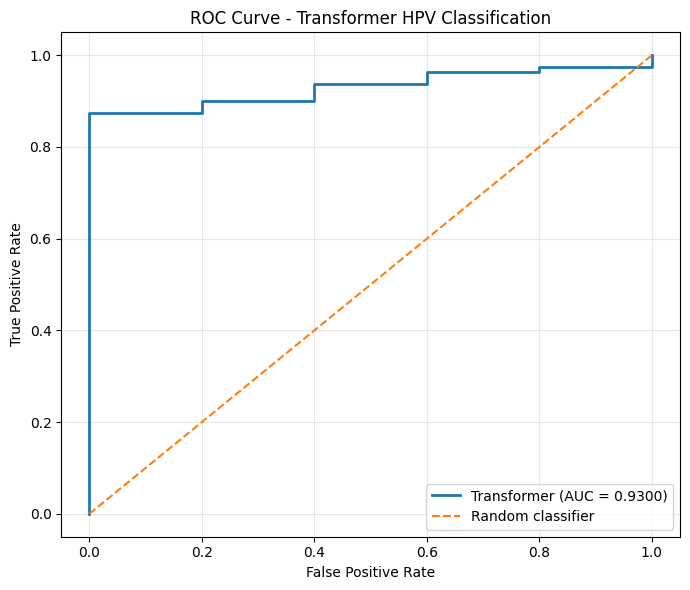

AUC: 0.9300


In [1]:
import os
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score


def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" # Required for newer PyTorch versions
    torch.use_deterministic_algorithms(True, warn_only=True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    np.random.seed(seed)
    random.seed(seed)


SEED = 42
seed_everything(seed=SEED)

import pandas as pd

sheet_id = "1DGDH2e6dEkpdwwtCvH6ds1CwJT2Hdmkv"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

df = pd.read_csv(url)

print(df.shape)
df.head()


df = df.dropna(subset=['HPV Status'])

tobacco_mode = df['Tobacco Consumption'].mode()[0]

df['Tobacco Consumption'] = df[
    'Tobacco Consumption'
].fillna(tobacco_mode)

alcohol_mode = df['Alcohol Consumption'].mode()[0]

df['Alcohol Consumption'] = df[
    'Alcohol Consumption'
].fillna(alcohol_mode)

df = df.drop(
    columns=[
        'PatientID',
        'CenterID',
        'Task 1',
        'Task 2',
        'Task 3'
    ]
)

df = df.dropna()

print(df.shape)

df['T-stage'] = df['T-stage'].replace({
    'T0': 0,
    'T1': 1,
    'T2': 2,
    'T3': 3,
    'T4': 4
})

df['N-stage'] = df['N-stage'].replace({
    'N0': 0,
    'N1': 1,
    'N2': 2,
    'N3': 3
})

df['M-stage'] = df['M-stage'].replace({
    'M0': 0,
    'M1': 1
})

X = df[
    [
        'Age',
        'Gender',
        'Tobacco Consumption',
        'Alcohol Consumption',
        'Performance Status',
        'Relapse',
        'RFS',
        'Treatment',
        'T-stage',
        'N-stage',
        'M-stage'
    ]
]

y = df['HPV Status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

print('train sample:', y_train.value_counts(), '\n')
print('test sample:', y_test.value_counts())

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# Torch Conversion
# No SMOTE
# ============================================================

X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train.to_numpy())

X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test.to_numpy())


# Model Architecture
# Transformer-based model for tabular classification

class HPVNet_Transformer(nn.Module):

    def __init__(
        self,
        num_features=11,
        d_model=32,
        nhead=4,
        num_layers=2,
        dim_feedforward=64,
        dropout=0.1,
        num_classes=2
    ):
        super().__init__()

        self.num_features = num_features
        self.d_model = d_model

        # Convert each scalar feature into a d_model-dimensional token
        self.feature_projection = nn.Linear(1, d_model)

        # Learnable embedding identifying each feature
        self.feature_embedding = nn.Parameter(
            torch.zeros(1, num_features, d_model)
        )

        # Learnable classification token
        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.feature_embedding, mean=0.0, std=0.02)
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)

        nn.init.xavier_uniform_(self.feature_projection.weight)
        nn.init.zeros_(self.feature_projection.bias)

    def forward(self, x):
        batch_size = x.size(0)

        # Input: [batch_size, 11]
        # Tokens: [batch_size, 11, d_model]
        x = x.unsqueeze(-1)
        x = self.feature_projection(x)

        # Distinguish Age token from Gender, Tobacco, T-stage, etc.
        x = x + self.feature_embedding

        # Add classification token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Model interactions between tabular features
        x = self.transformer(x)

        # Use the CLS token for classification
        x = self.norm(x[:, 0])

        logits = self.classifier(x)

        return logits


# Defining model, and optimisation function/parameters

model = HPVNet_Transformer()

weights = torch.tensor([3.0, 1.0], dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=0.001,
#     weight_decay=0.01
# )

if os.path.exists("best_model_transformer.pth"):
    os.remove("best_model_transformer.pth")


# Training the model

epochs = 500

best_val_loss = float('inf')
best_epoch = 0

for epoch in range(epochs):

    model.train()

    outputs = model(X_train)

    train_loss = criterion(
        outputs,
        y_train
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        test_outputs = model(X_test)

        test_loss = criterion(
            test_outputs,
            y_test
        )

    if test_loss.item() < best_val_loss:

        best_val_loss = test_loss.item()

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_model_transformer.pth"
        )

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch+1}, "
            f"Train={train_loss.item():.4f}, "
            f"Test={test_loss.item():.4f}",
            f"Best Epoch={best_epoch}"
        )


print("Best Test Loss =", best_val_loss)
print("Best Epoch =", best_epoch)


# Inferencing the model

model.load_state_dict(
    torch.load("best_model_transformer.pth")
)

model.eval()

with torch.no_grad():

    outputs = model(X_test)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predicted = torch.argmax(
        outputs,
        dim=1
    )


results = classification_report(
    y_test.numpy(),
    predicted.numpy(),
    digits=4
)

print('results:', results)


# Balanced Accuracy

bal_acc = balanced_accuracy_score(
    y_test.numpy(),
    predicted.numpy()
)

f1 = f1_score(
    y_test.numpy(),
    predicted.numpy()
)


y_prob = probabilities.cpu().numpy()

if y_prob.shape[1] == 2:

    auc = roc_auc_score(
        y_test.numpy(),
        y_prob[:, 1]
    )

else:

    auc = roc_auc_score(
        y_test.numpy(),
        y_prob,
        multi_class="ovr",
        average="weighted"
    )


print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"F1-score:          {f1:.4f}")
print(f"AUC:               {auc:.4f}")


# ============================================================
# ROC / AUC CURVE
# ============================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


# Probability of HPV positive

y_score = y_prob[:, 1]


# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test.numpy(),
    y_score
)


# Calculate AUC

auc = roc_auc_score(
    y_test.numpy(),
    y_score
)


# Plot ROC curve

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Transformer (AUC = {auc:.4f})'
)


# Random classifier reference line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Random classifier'
)


plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title(
    'ROC Curve - Transformer HPV Classification'
)

plt.legend(
    loc='lower right'
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

print(f"AUC: {auc:.4f}")